# Model 5 — Capacity Allocation

**Question Answered:** _How to optimize utilization against margin across workloads._

**Question:** Given a fixed GPU budget, how should capacity split across workloads to maximise blended margin, and what constrains the gain?

_Consumes Model 4's fleet constraint and Model 1's per-product cost basis._

## 1. Inputs & Assumptions

- **Source:** `inference_events` joined to `cost_constants` (query Q5).
- **Price card (assumption):** interactive **$0.0009 / 1K output tokens**, batch **$0.0004 / 1K** — interactive is the premium, latency-sensitive tier.
- **Margin:** `(revenue − cost) / revenue`; we compare **margin per GPU-second** across workloads since GPU-seconds are the scarce, fixed resource.
- **Reallocation:** hold total GPU-seconds fixed (Model 4's fleet) and shift the interactive/batch split.
- **Utilisation ceiling (assumption):** efficient operation tops out near **85%**; beyond that, queueing erodes the latency SLO and the reallocation gain is capped.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({'figure.figsize':(9,4.5),'axes.spines.top':False,'axes.spines.right':False,
                     'axes.grid':True,'grid.alpha':0.3,'font.size':11})
NAVY, AMBER, GREY = '#1F3864', '#E1A140', '#9AA5B1'

conn = sqlite3.connect('../data/events.db')
pd.set_option('display.float_format', lambda v: f'{v:,.6f}')
print('rows:', pd.read_sql_query('SELECT COUNT(*) n FROM inference_events', conn).n[0])

rows: 120000


## 2. Working Code

### 2a. Margin per GPU-second by workload (query Q5)

In [2]:
q = '''
SELECT e.workload_type,
       SUM(e.gpu_seconds)   AS gpu_seconds,
       SUM(e.tokens_output) AS output_tokens,
       AVG(e.utilization_pct) AS avg_util,
       SUM(e.gpu_seconds * c.blended_cost_per_gpu_second) AS cost
FROM inference_events e
JOIN cost_constants c USING (gpu_type)
GROUP BY e.workload_type
'''
m = pd.read_sql_query(q, conn).set_index('workload_type')
PRICE = {'interactive':0.0009, 'batch':0.0004}      # $ / 1K output tokens
m['revenue']     = m.output_tokens/1000 * pd.Series(PRICE)
m['margin']      = (m.revenue - m.cost) / m.revenue
m['rev_per_gs']  = m.revenue / m.gpu_seconds
m['cost_per_gs'] = m.cost    / m.gpu_seconds
m['margin_per_gs'] = (m.revenue - m.cost) / m.gpu_seconds
m[['gpu_seconds','margin','margin_per_gs','avg_util']]

,gpu_seconds,margin,margin_per_gs,avg_util
workload_type,,,,
batch,"1,619.153190",0.591496,0.001818,78.408760
interactive,"5,329.239770",0.681410,0.002680,75.422988


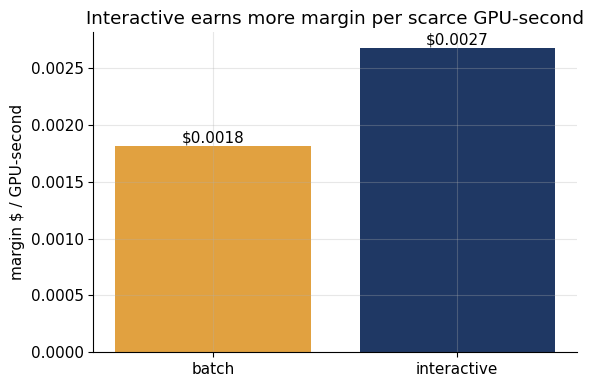

interactive margin/GPU-sec is 47% higher than batch


In [3]:
fig, ax = plt.subplots(figsize=(6,4))
ax.bar(m.index, m.margin_per_gs, color=[AMBER if i=='batch' else NAVY for i in m.index])
for x,v in enumerate(m.margin_per_gs):
    ax.text(x, v, f'${v:.4f}', ha='center', va='bottom')
ax.set_ylabel('margin $ / GPU-second'); ax.set_title('Interactive earns more margin per scarce GPU-second')
plt.tight_layout(); plt.show()
prem = 100*(m.margin_per_gs['interactive']/m.margin_per_gs['batch']-1)
print(f'interactive margin/GPU-sec is {prem:.0f}% higher than batch')

### 2b. Blended margin as a function of the interactive capacity share

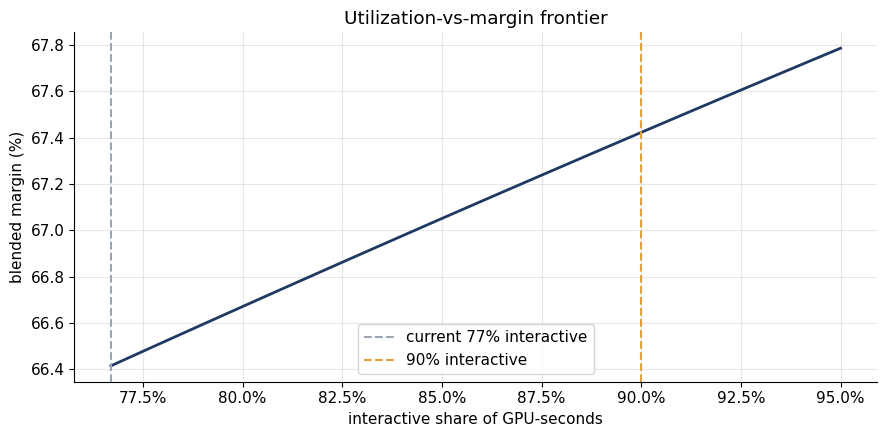

In [4]:
tot_gs = m.gpu_seconds.sum()
cur_frac = m.gpu_seconds['interactive']/tot_gs
def blended_margin(frac_int):
    gi, gb = tot_gs*frac_int, tot_gs*(1-frac_int)
    rev  = gi*m.rev_per_gs['interactive']  + gb*m.rev_per_gs['batch']
    cost = gi*m.cost_per_gs['interactive'] + gb*m.cost_per_gs['batch']
    return (rev-cost)/rev

fracs = np.linspace(cur_frac, 0.95, 40)
fig, ax = plt.subplots()
ax.plot(fracs, [100*blended_margin(f) for f in fracs], color=NAVY, lw=2)
ax.axvline(cur_frac, color=GREY, ls='--', label=f'current {cur_frac:.0%} interactive')
ax.axvline(0.90, color=AMBER, ls='--', label='90% interactive')
ax.set_xlabel('interactive share of GPU-seconds'); ax.set_ylabel('blended margin (%)')
ax.set_title('Utilization-vs-margin frontier'); ax.legend()
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout(); plt.show()

### 2c. The reallocation gain, and the binding constraint

In [5]:
lift = 100*(blended_margin(0.90) - blended_margin(cur_frac))
print(f'current interactive share : {cur_frac:.0%}')
print(f'blended margin now        : {blended_margin(cur_frac):.1%}')
print(f'blended margin @ 90% int. : {blended_margin(0.90):.1%}')
print(f'lift from reallocation    : +{lift:.1f} margin points')
print(f'avg utilization (interactive {m.avg_util["interactive"]:.0f}%, '
      f'batch {m.avg_util["batch"]:.0f}%) vs ~85% efficient ceiling')

current interactive share : 77%
blended margin now        : 66.4%
blended margin @ 90% int. : 67.4%
lift from reallocation    : +1.0 margin points
avg utilization (interactive 75%, batch 78%) vs ~85% efficient ceiling


## 3. Insight

> **Every scarce GPU-second is worth ~47% more in interactive than in batch — but most of that reallocation is already done, so the remaining lever is utilisation, not mix.** Interactive earns **~47% more margin per GPU-second**; pushing the interactive share from **~77% to 90%** lifts blended margin from **66.4% to ~67.4% (+1.0 point)**. The gain is modest precisely *because* capacity already favours the high-margin tier.

**The binding constraint is utilisation.** With the fleet running ~76% and an efficient ceiling near 85%, the real margin headroom is closing the **~9-point utilisation gap** (and the cache lever in Model 3) — not further mix shifts. "Reallocate to interactive" is right but nearly exhausted; "raise utilisation toward 85% without breaking the latency SLO" is the live lever.

**Closes the loop:** allocation (here) + cache ROI (Model 3) + demand (Model 4) together set the margin trajectory the capstone integrates.